# Ankara Rent Price Prediction

## Projenin Amacı

Bu projenin amacı, Ankara kiralık ev ilanlarından elde edilen verilerle kira fiyatını tahmin eden regression modelleri geliştirmektir.

Veri seti önce Jupyter Notebook üzerinde Emlakjet sitesinden web scraping ile toplanmış ve `ankara_rent_data.csv` dosyası olarak kaydedilmiştir. Bu Kaggle notebook üzerinde ise veri temizleme, görselleştirme, klasik regression modelleri ve TensorFlow/Keras deep learning modeli uygulanacaktır.

## Yol Haritası

1. Web scraping ile oluşturulan veri setini yükleme
2. Proje görselini gösterme
3. Veri temizleme
4. Grafiklerle veri analizi
5. Linear Regression, Random Forest ve Gradient Boosting modelleri kurma
6. TensorFlow/Keras deep learning modeli kurma
7. Modelleri karşılaştırma
8. Sonuçları değerlendirme


In [1]:
# Bu hücrede Kaggle'a yüklediğimiz dosyaların bulunduğu klasörü kontrol ediyoruz.
# Böylece resim ve CSV dosyasının tam yolunu öğreneceğiz.

import os

DATA_PATH = "/kaggle/input/datasets/hakankahraman571/ankara-rent-price-prediction-data"
os.listdir(DATA_PATH)


['Ankara Emlak Resim.jpg',
 'Ankara_Rent_Price_Prediction.ipynb.ipynb',
 'ankara_rent_data.csv']

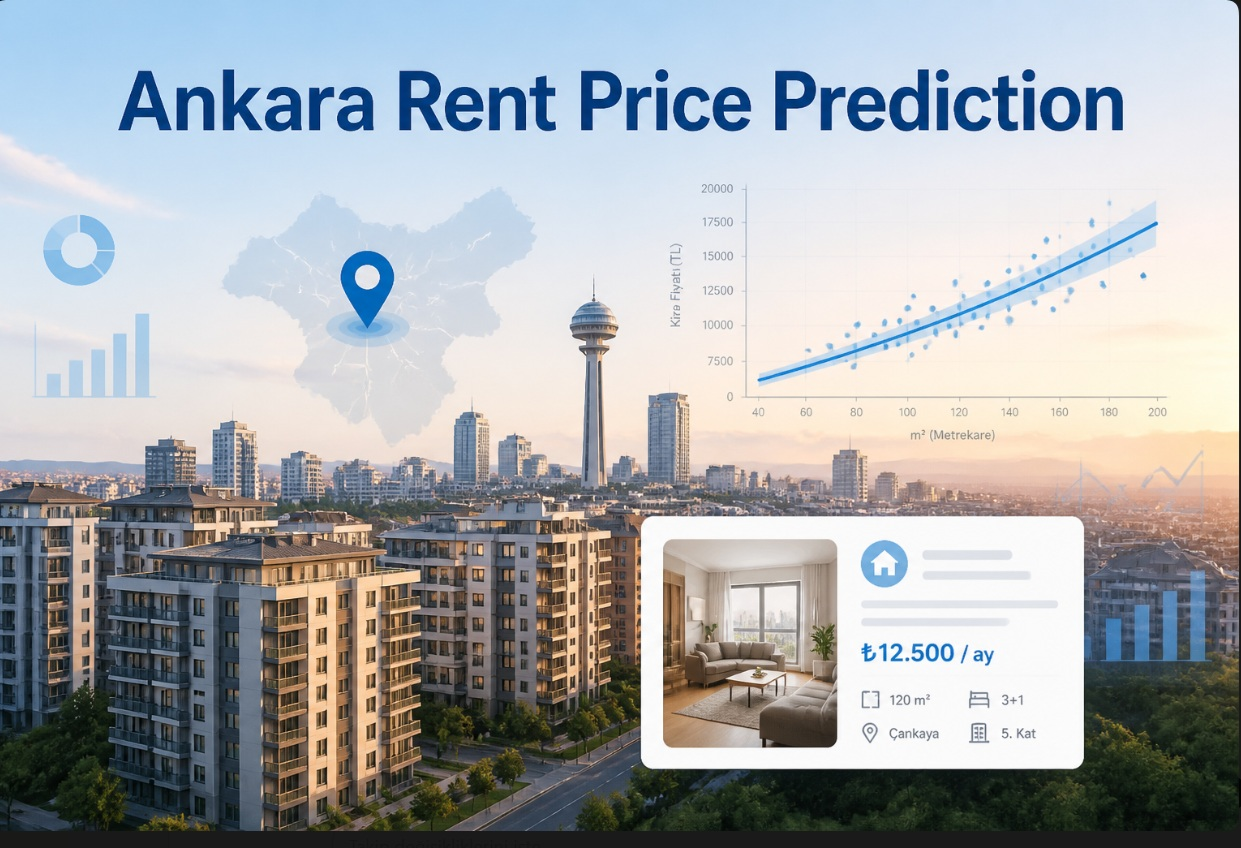

In [2]:
# Bu hücrede Kaggle'a yüklediğimiz proje görselini notebook içinde gösteriyoruz.
# Görsel, Ankara kira fiyatı tahmin projesini daha anlaşılır hale getirir.

from IPython.display import Image, display

display(Image(filename=DATA_PATH + "/Ankara Emlak Resim.jpg", width=900))


In [3]:
# Bu hücrede Kaggle'a yüklediğimiz CSV veri setini okuyoruz.
# Veri seti daha önce Jupyter Notebook üzerinde web scraping ile oluşturulmuştur.

import pandas as pd

rent_df = pd.read_csv(DATA_PATH + "/ankara_rent_data.csv")
rent_df.head()


,url,price,district,neighborhood,room,net_m2,building_age,floor,heating
0,https://www.emlakjet.com/ilan/tepebasi-mahalle...,"20,000",Keçiören,Tepebaşı Mahallesi,3+1,95.0,21 Ve Üzeri,1.Kat,Kombi Doğalgaz
1,https://www.emlakjet.com/ilan/lummo-dan-akag-l...,"50,000",Keçiören,Ovacık Mahallesi,4+1,190.0,5-10,17.Kat,Merkezi (Pay Ölçer)
2,https://www.emlakjet.com/ilan/arel-den-yeni-bi...,"50,000",Çankaya,Kazım Özalp Mahallesi,1+1,50.0,0 (Yeni),Düz Giriş (Zemin),Kombi Doğalgaz
3,https://www.emlakjet.com/ilan/yildirim-emlak-t...,"20,000",Polatlı,Cumhuriyet Mahallesi,3+1,125.0,21 Ve Üzeri,2.Kat,Kombi Doğalgaz
4,https://www.emlakjet.com/ilan/uzman-emlak-ofis...,"38,500",Keçiören,İncirli Mahallesi,3+1,139.0,11-15,2.Kat,Kombi Doğalgaz


## Veri Temizleme

Bu bölümde yüklenen kira verisi modelleme için hazırlanacaktır.

Kira fiyatı, metrekare ve oda sayısı gibi alanlar sayısal hale getirilecek; eksik değerler temizlenecek ve modelin kullanacağı veri seti oluşturulacaktır.


In [4]:
# Bu hücrede kira fiyatı ve metrekare bilgilerini sayısal hale getiriyoruz.
# Model kurarken bu değerlerin sayı formatında olması gerekir.

clean_df = rent_df.copy()

clean_df["price"] = (
    clean_df["price"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
)

clean_df["price"] = pd.to_numeric(clean_df["price"], errors="coerce")
clean_df["net_m2"] = pd.to_numeric(clean_df["net_m2"], errors="coerce")

clean_df[["price", "net_m2"]].head()


,price,net_m2
0,20000,95.0
1,50000,190.0
2,50000,50.0
3,20000,125.0
4,38500,139.0


In [5]:
# Bu hücrede oda sayısı bilgisini sayısal hale getiriyoruz.
# Örneğin 3+1 ifadesi toplam 4 oda olarak hesaplanır.

def room_to_number(room):
    try:
        parts = room.split("+")
        return int(parts[0]) + int(parts[1])
    except:
        return None

clean_df["room_count"] = clean_df["room"].apply(room_to_number)

clean_df[["room", "room_count"]].head()


,room,room_count
0,3+1,4.0
1,4+1,5.0
2,1+1,2.0
3,3+1,4.0
4,3+1,4.0


In [6]:
# Bu hücrede oda sayısını sayısal hale getiriyoruz ve model için temiz tablo oluşturuyoruz.
# Örneğin 3+1 ifadesi toplam 4 oda olarak hesaplanır.

def room_to_number(room):
    try:
        parts = room.split("+")
        return int(parts[0]) + int(parts[1])
    except:
        return None

clean_df["room_count"] = clean_df["room"].apply(room_to_number)

model_df = clean_df[["price", "district", "net_m2", "building_age", "floor", "heating", "room_count"]].dropna()
model_df = model_df[(model_df["price"] >= 5000) & (model_df["price"] <= 200000)]

print("Temiz veri satır sayısı:", model_df.shape[0])
model_df.head()


Temiz veri satır sayısı: 30


,price,district,net_m2,building_age,floor,heating,room_count
0,20000,Keçiören,95.0,21 Ve Üzeri,1.Kat,Kombi Doğalgaz,4.0
1,50000,Keçiören,190.0,5-10,17.Kat,Merkezi (Pay Ölçer),5.0
2,50000,Çankaya,50.0,0 (Yeni),Düz Giriş (Zemin),Kombi Doğalgaz,2.0
3,20000,Polatlı,125.0,21 Ve Üzeri,2.Kat,Kombi Doğalgaz,4.0
4,38500,Keçiören,139.0,11-15,2.Kat,Kombi Doğalgaz,4.0


## Veri Görselleştirme

Bu bölümde temizlenmiş veri seti grafiklerle incelenecektir.

Grafikler sayesinde kira fiyatlarının dağılımı, metrekare ile kira ilişkisi ve ilçelere göre kira değişimi daha kolay yorumlanacaktır.


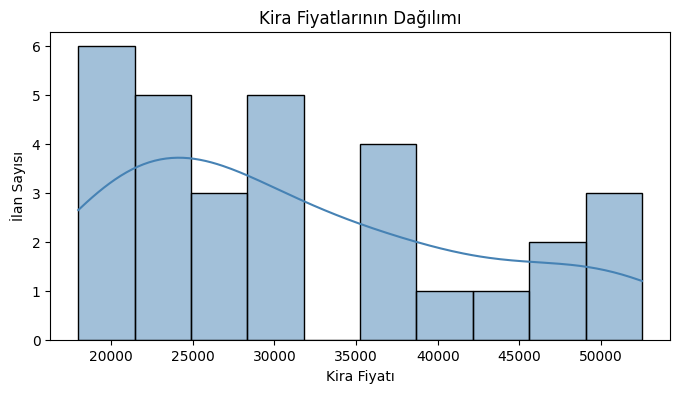

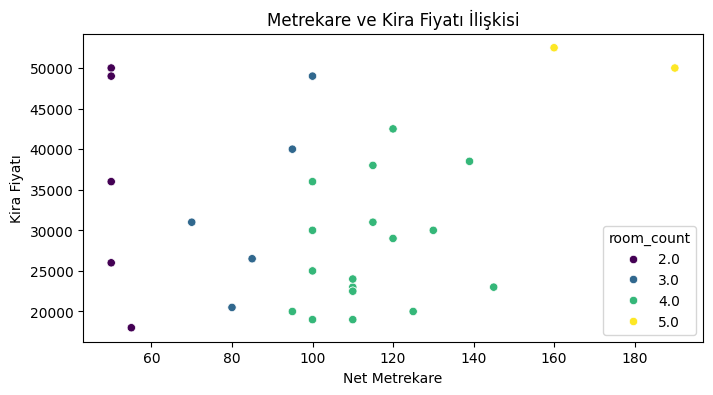

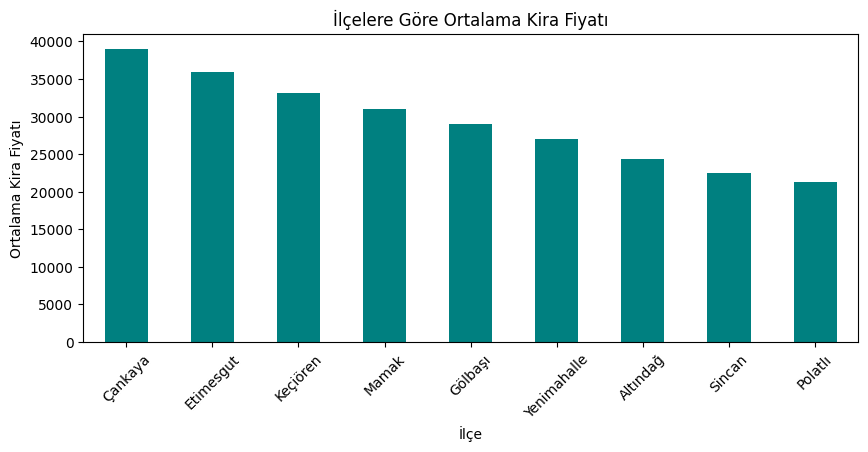

In [7]:
# Bu hücrede kira fiyatlarının dağılımını, metrekare ilişkisini ve ilçelere göre ortalama kiraları gösteriyoruz.
# Grafikler veriyi daha kolay anlamamızı sağlar.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(model_df["price"], bins=10, kde=True, color="steelblue")
plt.title("Kira Fiyatlarının Dağılımı")
plt.xlabel("Kira Fiyatı")
plt.ylabel("İlan Sayısı")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=model_df, x="net_m2", y="price", hue="room_count", palette="viridis")
plt.title("Metrekare ve Kira Fiyatı İlişkisi")
plt.xlabel("Net Metrekare")
plt.ylabel("Kira Fiyatı")
plt.show()

district_price = model_df.groupby("district")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))
district_price.plot(kind="bar", color="teal")
plt.title("İlçelere Göre Ortalama Kira Fiyatı")
plt.xlabel("İlçe")
plt.ylabel("Ortalama Kira Fiyatı")
plt.xticks(rotation=45)
plt.show()


## Grafiklerin Yorumu

Kira fiyatı dağılımına bakıldığında ilanların çoğunun 20.000 TL ile 35.000 TL arasında olduğu görülmektedir.

Metrekare ve kira fiyatı grafiğinde genel olarak metrekare arttıkça kira fiyatının da arttığı görülmektedir. Ancak bazı küçük metrekareli ilanların yüksek fiyatlı olması, konum ve ev özelliklerinin de fiyat üzerinde etkili olduğunu göstermektedir.

İlçelere göre ortalama kira grafiğinde Çankaya ve Etimesgut gibi ilçelerde ortalama kira fiyatlarının daha yüksek olduğu görülmektedir.



## Modelleme Hazırlığı

Bu bölümde veri seti makine öğrenmesi modelleri için hazırlanacaktır.

Modelin tahmin etmeye çalışacağı hedef değişken kira fiyatıdır. Metrekare, oda sayısı, ilçe, bina yaşı, kat ve ısıtma tipi gibi bilgiler ise tahmin için kullanılacak özelliklerdir.

Kategorik değişkenler sayısal hale getirilecek ve veri eğitim-test olarak ikiye ayrılacaktır.


In [8]:
# Bu hücrede hedef değişkeni ve özellikleri ayırıyoruz.
# Kategorik sütunları one-hot encoding yöntemiyle sayısal hale getiriyoruz.

from sklearn.model_selection import train_test_split

X = model_df.drop("price", axis=1)
y = model_df["price"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim veri sayısı:", X_train.shape[0])
print("Test veri sayısı:", X_test.shape[0])
print("Özellik sayısı:", X_train.shape[1])


Eğitim veri sayısı: 24
Test veri sayısı: 6
Özellik sayısı: 28


## Regression Modelleri

Bu bölümde kira fiyatı tahmini için üç farklı klasik regression modeli eğitilecektir.

Kullanılacak modeller:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

Modeller MAE, RMSE ve R2 değerleri ile karşılaştırılacaktır.


In [9]:
# Bu hücrede üç farklı regression modelini eğitiyoruz.
# Her modelin test verisi üzerindeki MAE, RMSE ve R2 değerlerini hesaplıyoruz.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df


,Model,MAE,RMSE,R2
0,Linear Regression,26727.514256,33705.729294,-23.043940
1,Random Forest,9934.166667,10726.946405,-1.435288
2,Gradient Boosting,11542.854823,13139.933512,-2.654134


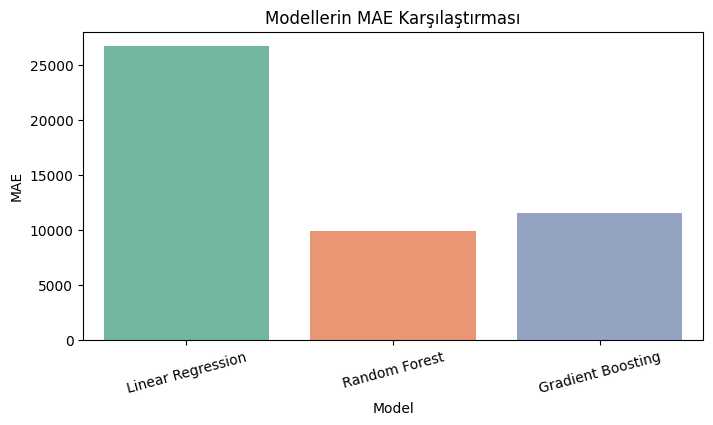

In [10]:
# Bu hücrede modellerin MAE değerlerini grafikle karşılaştırıyoruz.
# MAE değeri düşük olan model daha başarılı kabul edilir.

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="Model", y="MAE", hue="Model", palette="Set2", legend=False)
plt.title("Modellerin MAE Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.show()


## Klasik Model Sonuçlarının Yorumu

Üç farklı regression modeli aynı eğitim ve test verisi üzerinde denenmiştir.

MAE değerine göre en düşük hata Random Forest modelinde elde edilmiştir. Bu nedenle klasik makine öğrenmesi modelleri arasında en başarılı model Random Forest olarak seçilmiştir.

R2 değerlerinin düşük çıkmasının temel nedeni veri setinin küçük olmasıdır. Veri setinde yalnızca 30 temiz ilan bulunduğu için modelin genelleme başarısı sınırlı kalmıştır.


## TensorFlow/Keras Deep Learning Modeli

Bu bölümde TensorFlow ve Keras kullanılarak kira fiyatı tahmini için yapay sinir ağı modeli kurulacaktır.

Veri seti küçük olduğu için deep learning modelinden çok yüksek başarı beklenmemektedir. Ancak bu bölümde amaç, regression problemi için Keras ile model kurma adımlarını göstermektir.


In [11]:
# Bu hücrede TensorFlow/Keras modeli için verileri ölçeklendiriyoruz.
# Ölçeklendirme, deep learning modelinin daha dengeli öğrenmesine yardımcı olur.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirilmiş eğitim verisi:", X_train_scaled.shape)
print("Ölçeklendirilmiş test verisi:", X_test_scaled.shape)


Ölçeklendirilmiş eğitim verisi: (24, 28)
Ölçeklendirilmiş test verisi: (6, 28)


In [12]:
# Bu hücrede TensorFlow/Keras kullanarak basit bir yapay sinir ağı modeli kuruyoruz.
# Modelin amacı verilen ev özelliklerinden kira fiyatını tahmin etmektir.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

keras_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

keras_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = keras_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=4,
    validation_split=0.2,
    verbose=0
)

print("Keras modeli eğitildi.")


2026-05-12 09:09:37.635648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778576977.883446      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778576977.953724      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778576978.541828      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778576978.541873      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778576978.541876      16 computation_placer.cc:177] computation placer alr

Keras modeli eğitildi.


In [13]:
# Bu hücrede Keras modelinin test verisi üzerindeki tahmin başarısını ölçüyoruz.
# MAE, RMSE ve R2 değerleri klasik modellerle karşılaştırmak için hesaplanır.

keras_prediction = keras_model.predict(X_test_scaled).flatten()

keras_mae = mean_absolute_error(y_test, keras_prediction)
keras_rmse = np.sqrt(mean_squared_error(y_test, keras_prediction))
keras_r2 = r2_score(y_test, keras_prediction)

keras_result = pd.DataFrame({
    "Model": ["Keras Neural Network"],
    "MAE": [keras_mae],
    "RMSE": [keras_rmse],
    "R2": [keras_r2]
})

keras_result


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


,Model,MAE,RMSE,R2
0,Keras Neural Network,28607.857422,29429.414401,-17.329958


In [14]:
# Bu hücrede klasik regression modelleri ile Keras modelinin sonuçlarını birleştiriyoruz.
# Böylece tüm modelleri aynı tabloda karşılaştırabiliriz.

all_results = pd.concat([results_df, keras_result], ignore_index=True)

all_results


,Model,MAE,RMSE,R2
0,Linear Regression,26727.514256,33705.729294,-23.043940
1,Random Forest,9934.166667,10726.946405,-1.435288
2,Gradient Boosting,11542.854823,13139.933512,-2.654134
3,Keras Neural Network,28607.857422,29429.414401,-17.329958


In [15]:
# Bu hücrede klasik regression modelleri ile Keras modelinin sonuçlarını birleştiriyoruz.
# Böylece tüm modelleri aynı tabloda karşılaştırabiliriz.

all_results = pd.concat([results_df, keras_result], ignore_index=True)
all_results


,Model,MAE,RMSE,R2
0,Linear Regression,26727.514256,33705.729294,-23.043940
1,Random Forest,9934.166667,10726.946405,-1.435288
2,Gradient Boosting,11542.854823,13139.933512,-2.654134
3,Keras Neural Network,28607.857422,29429.414401,-17.329958


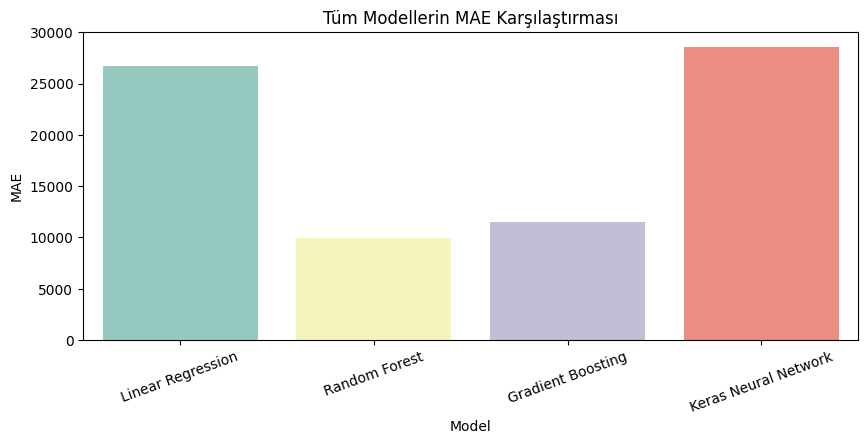

In [16]:
# Bu hücrede tüm modellerin MAE değerlerini grafikle karşılaştırıyoruz.
# MAE değeri düşük olan model daha başarılıdır.

plt.figure(figsize=(10,4))
sns.barplot(data=all_results, x="Model", y="MAE", hue="Model", palette="Set3", legend=False)
plt.title("Tüm Modellerin MAE Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()


## Tüm Model Sonuçlarının Yorumu

Klasik makine öğrenmesi modelleri ve Keras deep learning modeli karşılaştırılmıştır.

MAE değerine göre en başarılı model Random Forest olmuştur. Random Forest modeli test verisinde en düşük ortalama hata değerini vermiştir.

Keras Neural Network modeli bu veri setinde başarılı sonuç vermemiştir. Bunun temel nedeni veri setinin çok küçük olmasıdır. Deep learning modelleri genellikle daha fazla veri ile daha iyi sonuç verir.

Bu nedenle bu proje için en uygun model Random Forest olarak değerlendirilmiştir.


In [17]:
# Bu hücrede en başarılı model olan Random Forest ile test verisi üzerinde tahmin yapıyoruz.
# Gerçek kira fiyatları ile tahmin edilen kira fiyatlarını karşılaştırıyoruz.

best_model = models["Random Forest"]
best_predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({
    "Gerçek Kira": y_test.values,
    "Tahmin Edilen Kira": best_predictions
})

prediction_df


,Gerçek Kira,Tahmin Edilen Kira
0,40000,28530.0
1,20500,30370.0
2,38000,33155.0
3,26000,39225.0
4,29000,24340.0
5,26500,42035.0


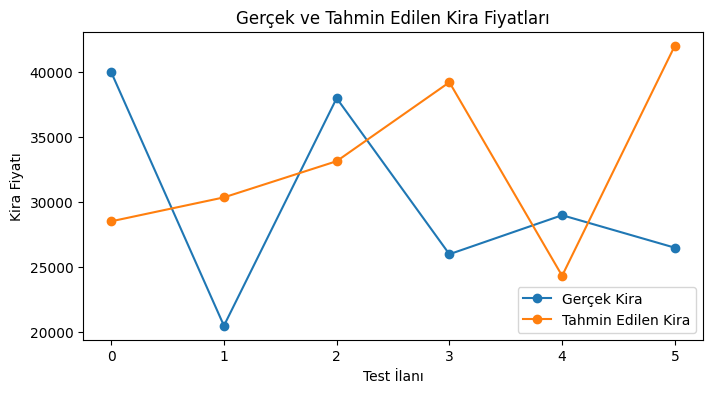

In [18]:
# Bu hücrede gerçek kira fiyatları ile tahmin edilen kira fiyatlarını grafikle karşılaştırıyoruz.
# Çizgiler birbirine yakınsa modelin tahmini daha başarılıdır.

plt.figure(figsize=(8,4))
plt.plot(prediction_df["Gerçek Kira"].values, marker="o", label="Gerçek Kira")
plt.plot(prediction_df["Tahmin Edilen Kira"].values, marker="o", label="Tahmin Edilen Kira")
plt.title("Gerçek ve Tahmin Edilen Kira Fiyatları")
plt.xlabel("Test İlanı")
plt.ylabel("Kira Fiyatı")
plt.legend()
plt.show()


## Tahmin Sonuçlarının Yorumu

Random Forest modeli ile test verisi üzerinde kira tahmini yapılmıştır.

Grafikte gerçek kira fiyatları ile tahmin edilen kira fiyatları karşılaştırılmıştır. Bazı ilanlarda tahminler gerçek değerlere yakınken, bazı ilanlarda hata oranı artmıştır.

Bu durumun en önemli nedeni veri setinin küçük olmasıdır. Daha fazla ilan verisi toplandığında modelin daha doğru tahminler yapması beklenir.


## Sonuç ve Değerlendirme

Bu projede Ankara kiralık daire ilanları kullanılarak kira fiyatı tahmini yapılmıştır. Projenin amacı, web scraping ile toplanan ilan verilerinden hareketle regression modelleri kurmak ve kira fiyatını tahmin etmektir.

Başlangıçta belirlenen hedeflere genel olarak ulaşılmıştır:

1. Proje konusu ve şehir belirlenmiştir.
2. Emlakjet sitesinden toplanan Ankara kiralık daire ilanları veri seti olarak kullanılmıştır.
3. Projeye uygun özel bir kapak görseli eklenmiştir.
4. Veri seti okunmuş ve gerekli alanlar seçilmiştir.
5. Kira fiyatı, metrekare ve oda sayısı gibi bilgiler sayısal hale getirilmiştir.
6. Veri seti grafiklerle incelenmiştir.
7. Linear Regression, Random Forest ve Gradient Boosting olmak üzere üç klasik regression modeli eğitilmiştir.
8. TensorFlow/Keras ile deep learning tabanlı regression modeli kurulmuştur.
9. Tüm modeller MAE, RMSE ve R2 değerleriyle karşılaştırılmıştır.
10. En başarılı model Random Forest olarak belirlenmiştir.
11. Random Forest modeli ile test verisi üzerinde kira tahmini yapılmıştır.

Model sonuçlarına göre en düşük MAE değerini Random Forest modeli vermiştir. Bu nedenle bu veri seti için en başarılı model Random Forest olmuştur.

Keras deep learning modeli bu küçük veri setinde başarılı sonuç vermemiştir. Bunun nedeni deep learning modellerinin genellikle daha fazla veriye ihtiyaç duymasıdır.

Genel olarak proje amacına ulaşmıştır. Ankara kiralık ev ilanlarından elde edilen bilgilerle kira fiyatı tahmini yapılmış, farklı regression modelleri karşılaştırılmış ve sonuçlar grafiklerle desteklenmiştir. Ancak veri seti yalnızca 30 temiz ilandan oluştuğu için model başarısı sınırlı kalmıştır. Daha fazla ilan verisi toplanarak modelin tahmin başarısı artırılabilir.
